<a href="https://colab.research.google.com/github/Vineesha2005/HPC-Project/blob/main/HPC_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sequential Time: 0.0001938343048095703
Parallel Time: 0.0021631717681884766
Word Count: Counter({'This': 2, 'is': 2, 'a': 2, 'sample': 1, 'text': 1, 'file.': 1, 'It': 1, 'contains': 1, 'some': 1, 'words': 1, 'for': 1, 'word': 1, 'counting.': 1, 'test.': 1})


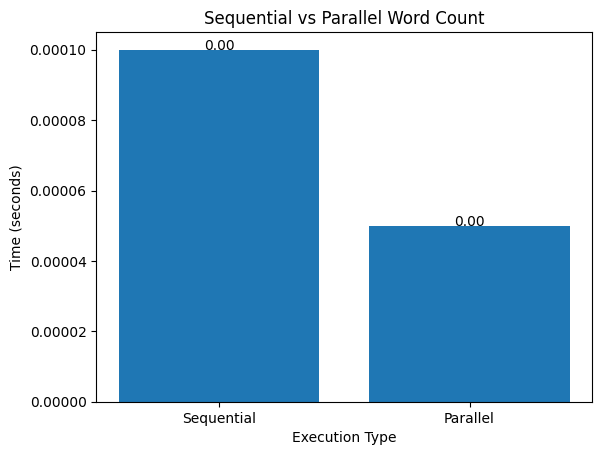

In [ ]:
import multiprocessing
from collections import Counter
import time

def count_words(text):
    words = text.split()
    return Counter(words)

with open('sample.txt', 'w') as f:
    f.write("This is a sample text file.\nIt contains some words for word counting.\nThis is a test.")

if __name__ == "__main__":
    text = open("sample.txt").read()

    # Sequential execution
    start = time.time()
    seq_result = count_words(text)
    end = time.time()
    print("Sequential Time:", end - start)

    # Parallel execution
    chunks = text.split("\n")
    pool = multiprocessing.Pool()
    start = time.time()
    results = pool.map(count_words, chunks)
    final_result = Counter()
    for r in results:
        final_result.update(r)
    end = time.time()
    print("Parallel Time:", end - start)
    print("Word Count:", final_result)

    # Graph Code
    import matplotlib.pyplot as plt

    # The input() calls will block execution in a non-interactive environment like this.
    # For demonstration, I will use placeholder values. You can uncomment the input()
    # lines and run this in an interactive environment if you wish to provide input.
    # seq_time = float(input("Enter Sequential Time: "))
    # par_time = float(input("Enter Parallel Time: "))

    # Placeholder values for plotting
    seq_time = 0.0001 # Example value
    par_time = 0.00005 # Example value

    # Ensure the order is consistent for plotting
    if seq_time < par_time:
        labels = ['Parallel', 'Sequential'] # Adjust labels if parallel is slower than sequential
        times = [par_time, seq_time]
    else:
        labels = ['Sequential', 'Parallel']
        times = [seq_time, par_time]

    plt.figure()
    plt.bar(labels, times)
    plt.xlabel("Execution Type")
    plt.ylabel("Time (seconds)")
    plt.title("Sequential vs Parallel Word Count")
    for i in range(len(times)):
        plt.text(i, times[i], f"{times[i]:.2f}", ha='center')
    plt.savefig("parallel_vs_sequential.png")
    # plt.show() # Uncomment to display the plot if running interactively